# ICPBL Wafer Open-Set Classification

This notebook trains and evaluates a ResNet18 wafer defect classifier for the ICPBL open-set task.

- Known labels: `DIE_BROKEN=0`, `NORMAL=1`, `NO_DIE=2`
- Unknown labels: `DIE_CRACK`, `DIE_INK`
- Submitted weight file: `model.pth`
- Canonical best run: `fs_r3_ac17_sharp110_p20_seed61`
- Open-set method: class-prototype patch distance with predicted-class score normalization and a validation-selected global threshold

Best canonical run summary: test open accuracy 0.8667, test open macro F1 0.8447, known accuracy 0.8000, unknown accuracy 0.9250.


In [1]:
import json
import os
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_recall_fscore_support
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

try:
    import wandb
except ImportError:
    wandb = None

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

In [2]:
KNOWN_LABELS = {
    'DIE_BROKEN': 0,
    'NORMAL': 1,
    'NO_DIE': 2,
}
ALL_TRUE_CLASSES = ['DIE_BROKEN', 'DIE_CRACK', 'DIE_INK', 'NORMAL', 'NO_DIE']
PRED_LABELS = ['DIE_BROKEN', 'NORMAL', 'NO_DIE']
UNKNOWN_PRED_NAME = 'UNKNOWN'
UNKNOWN_PRED_INDEX = 3

BEST_SEED = 61
BEST_THRESHOLD = 0.09808522504334695
BEST_CONFIG = {
    'experiment': 'fs_r3_ac17_sharp110_p20_seed61',
    'seed': BEST_SEED,
    'batch_size': 8,
    'epochs': 30,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'label_smoothing': 0.05,
    'image_size': 224,
    'augmentation': {
        'rotation_degrees': 5,
        'contrast_strength': 0.08,
        'sharpness_factor': 1.1,
        'sharpness_p': 0.2,
        'autocontrast_p': 0.17,
    },
}

ARTIFACT_PATHS = {
    'train_history_json': '../best_run/train_log.json',
    'ablation_metrics_json': '../Ablation study/ablation_metrics.json',
}

def display_path(path_value):
    path = Path(path_value).resolve()
    try:
        return str(path.relative_to(Path.cwd().resolve()))
    except ValueError:
        try:
            return f"{path.parent.name}/{path.name}"
        except Exception:
            return path.name

def find_data_root(start=Path.cwd()):
    start = Path(start).resolve()
    candidates = [start, *start.parents]
    candidates.extend([Path('/content'), Path('/kaggle/working')])
    for base in candidates:
        data_root = base / 'prepared_dataset_G5_622'
        if data_root.exists():
            return data_root
    raise FileNotFoundError('Place prepared_dataset_G5_622 next to this notebook or in a parent directory.')

def resolve_required_json_path(path_value, label):
    if path_value is None:
        raise ValueError(f"Set ARTIFACT_PATHS['{label}'] to the JSON file you want to load.")
    path = Path(path_value).expanduser()
    candidates = [path]
    if not path.is_absolute():
        candidates.append(Path.cwd() / path)
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f'{label} not found: {path}')

set_seed(BEST_SEED)
data_root = find_data_root()
print('seed:', BEST_SEED)
print('data root found:', data_root.name)


seed: 61
data root found: prepared_dataset_G5_622


In [3]:
class WaferKnownDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label, class_name = self.samples[index]
        image = Image.open(image_path).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image, label, class_name, str(image_path)


class WaferSplitDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, true_class = self.samples[index]
        image = Image.open(image_path).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image, true_class, str(image_path)


def collect_known_samples(data_root, split):
    split_root = Path(data_root) / split / 'G5'
    samples = []
    class_counts = Counter()
    for class_name, label in KNOWN_LABELS.items():
        image_dir = split_root / class_name / 'images'
        if not image_dir.exists():
            continue
        for image_path in sorted(image_dir.iterdir()):
            if image_path.is_file():
                samples.append((image_path, label, class_name))
                class_counts[class_name] += 1
    return samples, class_counts


def collect_split_samples(data_root, split, known_only=False):
    split_root = Path(data_root) / split / 'G5'
    class_names = list(KNOWN_LABELS) if known_only else ALL_TRUE_CLASSES
    samples = []
    class_counts = Counter()
    for class_name in class_names:
        image_dir = split_root / class_name / 'images'
        if not image_dir.exists():
            continue
        for image_path in sorted(image_dir.iterdir()):
            if image_path.is_file():
                samples.append((image_path, class_name))
                class_counts[class_name] += 1
    return samples, class_counts


def build_train_transform(image_size, aug_cfg):
    ops = [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(aug_cfg['rotation_degrees']),
    ]
    if aug_cfg['contrast_strength'] > 0:
        ops.append(transforms.ColorJitter(contrast=aug_cfg['contrast_strength']))
    if aug_cfg['sharpness_p'] > 0:
        ops.append(transforms.RandomAdjustSharpness(aug_cfg['sharpness_factor'], p=aug_cfg['sharpness_p']))
    if aug_cfg['autocontrast_p'] > 0:
        ops.append(transforms.RandomAutocontrast(p=aug_cfg['autocontrast_p']))
    ops.extend([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return transforms.Compose(ops)


def build_eval_transform(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


train_known, train_counts = collect_known_samples(data_root, 'train')
val_all, val_counts = collect_split_samples(data_root, 'val')
test_all, test_counts = collect_split_samples(data_root, 'test')
print('train known:', dict(train_counts))
print('val all:', dict(val_counts))
print('test all:', dict(test_counts))

train known: {'DIE_BROKEN': 26, 'NORMAL': 60, 'NO_DIE': 23}
val all: {'DIE_BROKEN': 8, 'DIE_CRACK': 20, 'DIE_INK': 20, 'NORMAL': 20, 'NO_DIE': 7}
test all: {'DIE_BROKEN': 8, 'DIE_CRACK': 20, 'DIE_INK': 20, 'NORMAL': 20, 'NO_DIE': 7}


## Dataset visualization

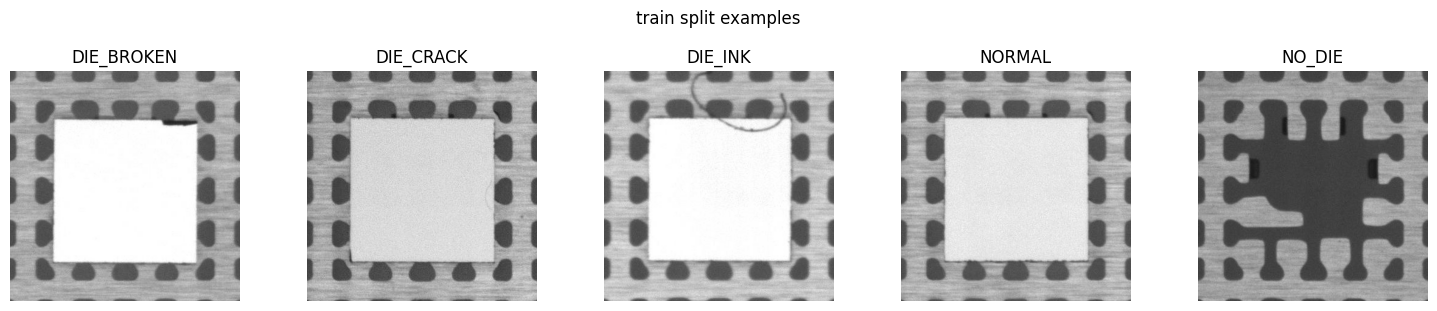

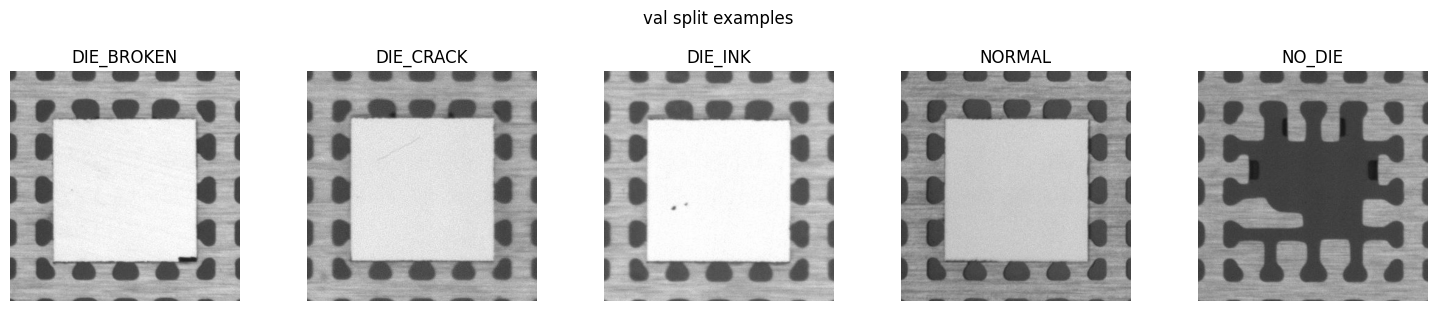

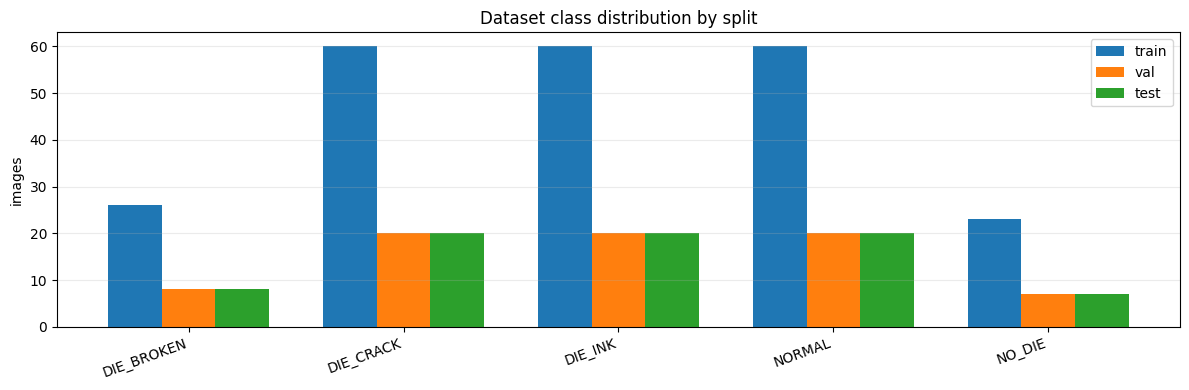

In [4]:
def show_class_examples(data_root, split='train'):
    fig, axes = plt.subplots(1, len(ALL_TRUE_CLASSES), figsize=(15, 3))
    for ax, class_name in zip(axes, ALL_TRUE_CLASSES):
        image_dir = Path(data_root) / split / 'G5' / class_name / 'images'
        paths = sorted([p for p in image_dir.iterdir() if p.is_file()]) if image_dir.exists() else []
        ax.axis('off')
        ax.set_title(class_name)
        if paths:
            ax.imshow(Image.open(paths[0]).convert('RGB'))
    fig.suptitle(f'{split} split examples', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_split_distributions(data_root):
    splits = ['train', 'val', 'test']
    counts_by_split = {}
    for split in splits:
        _, counts = collect_split_samples(data_root, split, known_only=False)
        counts_by_split[split] = [counts.get(class_name, 0) for class_name in ALL_TRUE_CLASSES]

    x = np.arange(len(ALL_TRUE_CLASSES))
    width = 0.25
    fig, ax = plt.subplots(figsize=(12, 4))
    for idx, split in enumerate(splits):
        ax.bar(x + (idx - 1) * width, counts_by_split[split], width, label=split)
    ax.set_xticks(x)
    ax.set_xticklabels(ALL_TRUE_CLASSES, rotation=20, ha='right')
    ax.set_ylabel('images')
    ax.set_title('Dataset class distribution by split')
    ax.legend()
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()


show_class_examples(data_root, split='train')
show_class_examples(data_root, split='val')
plot_split_distributions(data_root)

## Model training

The submitted `model.pth` was trained with this configuration. To verify notebook-side retraining, execute this notebook with environment variable `RUN_TRAINING=1`. The retrained probe checkpoint is saved separately and does not overwrite the submitted `model.pth`.


In [5]:
def build_model(pretrained=True):
    weights = ResNet18_Weights.DEFAULT if pretrained else None
    model = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, len(KNOWN_LABELS))
    return model


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    preds = []
    targets = []
    for images, labels, _, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
        targets.extend(labels.detach().cpu().numpy())
    precision, recall, f1, _ = precision_recall_fscore_support(targets, preds, average='macro', zero_division=0)
    return {
        'loss': total_loss / len(loader.dataset),
        'accuracy': accuracy_score(targets, preds),
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }


@torch.no_grad()
def eval_known_classifier(model, loader, criterion=None):
    model.eval()
    total_loss = 0.0
    preds = []
    targets = []
    for images, labels, _, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        if criterion is not None:
            total_loss += criterion(logits, labels).item() * images.size(0)
        preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
        targets.extend(labels.detach().cpu().numpy())
    precision, recall, f1, _ = precision_recall_fscore_support(targets, preds, average='macro', zero_division=0)
    metrics = {
        'accuracy': accuracy_score(targets, preds),
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }
    if criterion is not None:
        metrics['loss'] = total_loss / len(loader.dataset)
    return metrics


def train_model(output_path='notebook_retrained_model.pth', use_wandb=False):
    cfg = dict(BEST_CONFIG)
    set_seed(cfg.get('seed', BEST_SEED))
    image_size = cfg['image_size']
    batch_size = cfg['batch_size']
    train_samples, _ = collect_known_samples(data_root, 'train')
    val_samples, _ = collect_known_samples(data_root, 'val')
    train_loader = DataLoader(WaferKnownDataset(train_samples, build_train_transform(image_size, cfg['augmentation'])), batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(WaferKnownDataset(val_samples, build_eval_transform(image_size)), batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    model = build_model(pretrained=True).to(device)
    label_counts = Counter(label for _, label, _ in train_samples)
    class_weights = torch.tensor([len(train_samples) / (len(KNOWN_LABELS) * label_counts[i]) for i in range(len(KNOWN_LABELS))], dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=cfg['label_smoothing'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['learning_rate'], weight_decay=cfg['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'])

    run = None
    if use_wandb and wandb is not None:
        run = wandb.init(project='icpbl-wafer-open-set', name=cfg['experiment'], config=cfg)

    history = []
    best_val_loss = float('inf')
    best_state = None
    best_epoch = 0
    for epoch in range(1, cfg['epochs'] + 1):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics = eval_known_classifier(model, val_loader, criterion)
        scheduler.step()
        row = {'epoch': epoch, **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'val_{k}': v for k, v in val_metrics.items()}, 'lr': optimizer.param_groups[0]['lr']}
        history.append(row)
        if run is not None:
            wandb.log(row)
        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
        print(f"epoch {epoch:02d} train_loss={train_metrics['loss']:.4f} val_loss={val_metrics['loss']:.4f} val_f1={val_metrics['f1']:.4f}")

    checkpoint = {
        'model_state_dict': best_state,
        'cfg': cfg,
        'known_labels': KNOWN_LABELS,
        'image_size': image_size,
        'selection_metric': 'val_loss',
        'selection_value': float(best_val_loss),
        'best_epoch': int(best_epoch),
    }
    torch.save(checkpoint, output_path)
    if run is not None:
        wandb.finish()
    return checkpoint, history


TRAIN_OUTPUT_NAME = os.environ.get('TRAIN_OUTPUT_NAME', 'notebook_retrained_model.pth')
RUN_TRAINING = os.environ.get('RUN_TRAINING', '0') == '1'
USE_WANDB_FOR_TRAINING = os.environ.get('USE_WANDB', '0') == '1'
checkpoint = None
train_history = None
if RUN_TRAINING:
    checkpoint, train_history = train_model(TRAIN_OUTPUT_NAME, use_wandb=USE_WANDB_FOR_TRAINING)
    print('Saved notebook retraining probe to:', display_path(TRAIN_OUTPUT_NAME))


## Training and WandB metric visualizations

The curves below use the saved best-run history. These are the same metric keys logged by the training loop to WandB: loss, accuracy, precision, recall, and F1 for both train and validation splits.

Loaded training history from: best_run/train_log.json
Epochs: 30


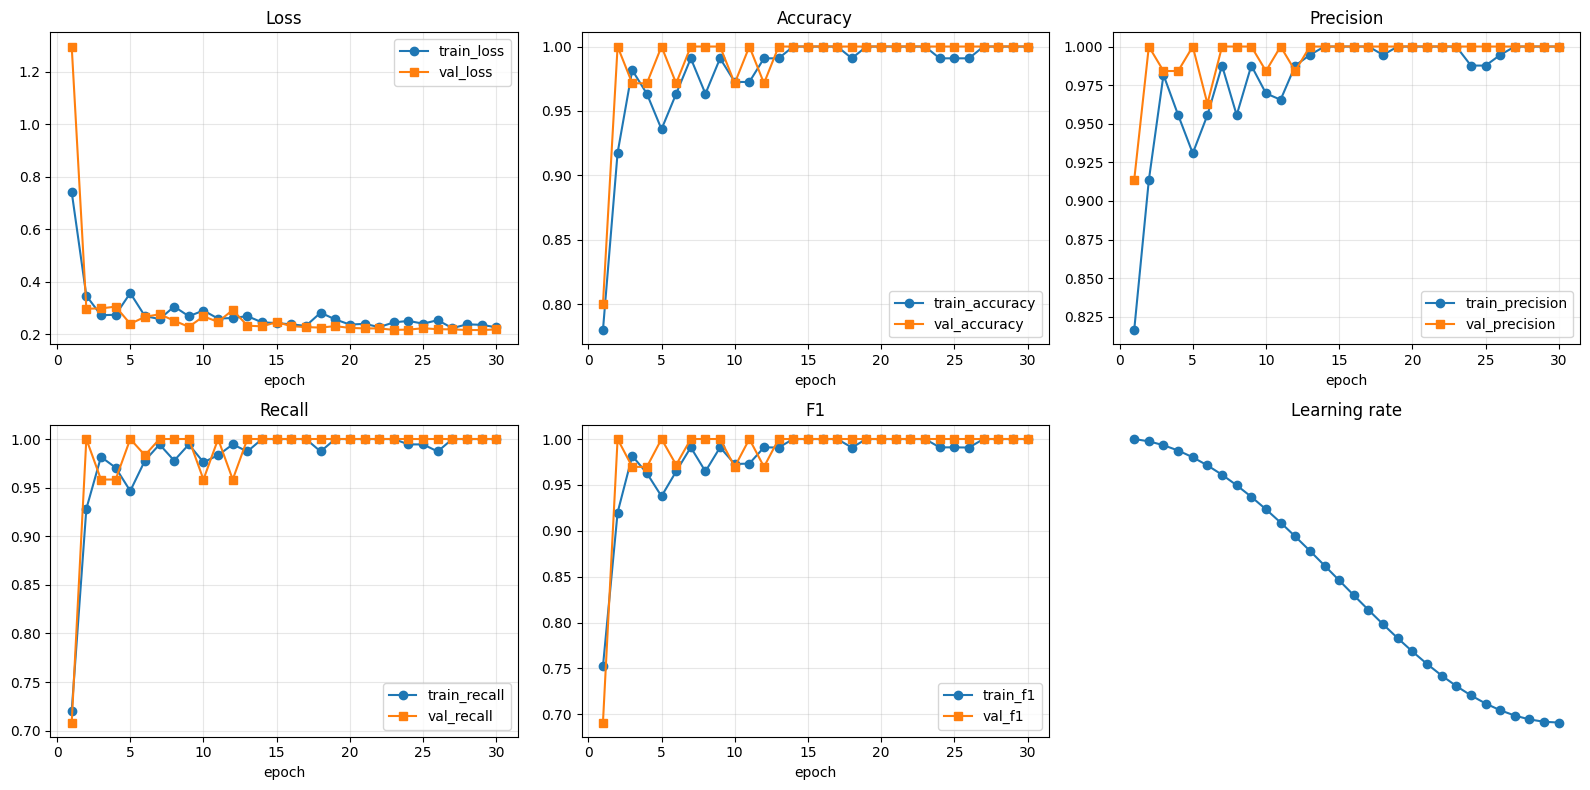

In [6]:
TRAIN_HISTORY_JSON_PATH = resolve_required_json_path(ARTIFACT_PATHS['train_history_json'], 'train_history_json')
with TRAIN_HISTORY_JSON_PATH.open() as f:
    BEST_TRAIN_HISTORY = json.load(f)

print('Loaded training history from:', display_path(TRAIN_HISTORY_JSON_PATH))
print('Epochs:', len(BEST_TRAIN_HISTORY))

def plot_training_curves(history):
    epochs = [row['epoch'] for row in history]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    metric_pairs = [
        ('loss', 'Loss'),
        ('accuracy', 'Accuracy'),
        ('precision', 'Precision'),
        ('recall', 'Recall'),
        ('f1', 'F1'),
    ]

    for ax, (metric_key, title) in zip(axes.flat, metric_pairs + [('lr', 'Learning rate')]):
        if metric_key == 'lr':
            ax.plot(epochs, [row['lr'] for row in history], marker='o')
            ax.set_title(title)
            ax.set_xlabel('epoch')
            ax.grid(alpha=0.3)
            continue
        ax.plot(epochs, [row[f'train_{metric_key}'] for row in history], marker='o', label=f'train_{metric_key}')
        ax.plot(epochs, [row[f'val_{metric_key}'] for row in history], marker='s', label=f'val_{metric_key}')
        ax.set_title(title)
        ax.set_xlabel('epoch')
        ax.grid(alpha=0.3)
        ax.legend()

    axes[1, 2].axis('off')
    plt.tight_layout()
    plt.show()

plot_training_curves(BEST_TRAIN_HISTORY)


### WandB visualization

The canonical seed-61 training history is loaded from `ARTIFACT_PATHS['train_history_json']` and can be re-logged to WandB using the same metric keys used by the training loop: `train_loss`, `train_accuracy`, `train_precision`, `train_recall`, `train_f1`, `val_loss`, `val_accuracy`, `val_precision`, `val_recall`, and `val_f1`. Use notebook-relative paths such as `../best_run/train_log.json`.

- Canonical seed-61 WandB run: [https://wandb.ai/minje227_hyu-hanyang-university/icpbl-wafer-open-set/runs/npixu0wh](https://wandb.ai/minje227_hyu-hanyang-university/icpbl-wafer-open-set/runs/npixu0wh)
- Set environment variable `LOG_SAVED_HISTORY_TO_WANDB=1` before execution to replay the saved history into a new run from this notebook.


In [7]:
SEED61_HISTORY_WANDB_RUN_URL = 'https://wandb.ai/minje227_hyu-hanyang-university/icpbl-wafer-open-set/runs/npixu0wh'

print('Canonical seed61 WandB run:', SEED61_HISTORY_WANDB_RUN_URL)
print('Training-history JSON:', display_path(TRAIN_HISTORY_JSON_PATH))

LOG_SAVED_HISTORY_TO_WANDB = os.environ.get('LOG_SAVED_HISTORY_TO_WANDB', '0') == '1'
if LOG_SAVED_HISTORY_TO_WANDB:
    if wandb is None:
        raise ImportError('Install wandb to log these metrics.')
    run = wandb.init(project='icpbl-wafer-open-set', name='seed61-history-visualization', config=BEST_CONFIG)
    for row in BEST_TRAIN_HISTORY:
        wandb.log(row, step=row['epoch'])
    wandb.finish()


Canonical seed61 WandB run: https://wandb.ai/minje227_hyu-hanyang-university/icpbl-wafer-open-set/runs/npixu0wh
Training-history JSON: best_run/train_log.json


## Open-set inference

For each image, the model first predicts one of the three known classes. The selected ResNet18 feature map is compared with the train-set prototype map of that predicted class. The mean of the top 12 patch distances is normalized by predicted class statistics from known training images. A validation-selected threshold rejects high-distance samples as `UNKNOWN`.

In [8]:
def true_class_to_index(true_class):
    return KNOWN_LABELS.get(true_class, UNKNOWN_PRED_INDEX)


def find_model_path(model_name='model.pth'):
    direct = Path(model_name)
    candidates = [direct, Path.cwd() / model_name]
    candidates.extend(parent / model_name for parent in Path.cwd().resolve().parents)
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'Could not find {model_name}. Keep it next to this notebook or in the working directory.')


def load_submitted_model(model_path='model.pth'):
    model_path = find_model_path(model_path)
    checkpoint = torch.load(model_path, map_location=device)
    image_size = checkpoint.get('image_size', 224)
    model = build_model(pretrained=False).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model, checkpoint, image_size


def forward_feature_map_and_logits(model, images, feature_layer='layer2'):
    x = model.conv1(images)
    x = model.bn1(x)
    x = model.relu(x)
    x = model.maxpool(x)
    x = model.layer1(x)
    x = model.layer2(x)
    if feature_layer == 'layer2':
        feature_map = x
    x = model.layer3(x)
    if feature_layer == 'layer3':
        feature_map = x
    x = model.layer4(x)
    if feature_layer == 'layer4':
        feature_map = x
    x = model.avgpool(x)
    x = torch.flatten(x, 1)
    logits = model.fc(x)
    return feature_map, logits


def normalize_patch_map(feature_map):
    return F.normalize(feature_map, dim=1, eps=1e-8)


@torch.no_grad()
def build_class_prototype_maps(model, loader, feature_layer='layer2'):
    feature_buckets = defaultdict(list)
    for images, true_classes, _ in loader:
        images = images.to(device, non_blocking=True)
        feature_maps, _ = forward_feature_map_and_logits(model, images, feature_layer)
        feature_maps = normalize_patch_map(feature_maps)
        for feature_map, true_class in zip(feature_maps, true_classes):
            feature_buckets[KNOWN_LABELS[true_class]].append(feature_map.detach().cpu())
    prototypes = []
    for class_idx in range(len(PRED_LABELS)):
        class_maps = torch.stack(feature_buckets[class_idx], dim=0)
        prototype = class_maps.mean(dim=0)
        prototype = normalize_patch_map(prototype.unsqueeze(0)).squeeze(0)
        prototypes.append(prototype)
    return torch.stack(prototypes, dim=0).to(device)


def topk_patch_score(feature_map, prototype_map, topk=12):
    distance_map = 1.0 - (feature_map * prototype_map).sum(dim=0)
    values = torch.topk(distance_map.flatten(), k=min(topk, distance_map.numel()), largest=True).values
    return values.mean(), distance_map


@torch.no_grad()
def run_open_set_rows(model, loader, prototype_maps, feature_layer='layer2', topk=12):
    rows = []
    for images, true_classes, paths in loader:
        images = images.to(device, non_blocking=True)
        feature_maps, logits = forward_feature_map_and_logits(model, images, feature_layer)
        probs = torch.softmax(logits, dim=1)
        pred_indices = probs.argmax(dim=1)
        confidences = probs.max(dim=1).values
        feature_maps = normalize_patch_map(feature_maps)
        for batch_idx, (true_class, path) in enumerate(zip(true_classes, paths)):
            pred_index = int(pred_indices[batch_idx].item())
            score, distance_map = topk_patch_score(feature_maps[batch_idx], prototype_maps[pred_index], topk=topk)
            rows.append({
                'path': path,
                'true_class': true_class,
                'true_index': true_class_to_index(true_class),
                'argmax_index': pred_index,
                'argmax_label': PRED_LABELS[pred_index],
                'confidence': float(confidences[batch_idx].item()),
                'anomaly_score': float(score.item()),
                'distance_map_mean': float(distance_map.mean().item()),
                'distance_map_max': float(distance_map.max().item()),
            })
    return rows


def compute_pred_class_normalization_stats(rows):
    stats = {}
    for class_idx, class_name in enumerate(PRED_LABELS):
        class_rows = [row for row in rows if row['true_class'] == class_name and row['argmax_index'] == class_idx]
        if not class_rows:
            class_rows = [row for row in rows if row['true_class'] == class_name]
        scores = np.array([row['anomaly_score'] for row in class_rows], dtype=float)
        mean = float(scores.mean())
        std = float(scores.std())
        if std < 1e-8:
            std = 1.0
        stats[class_idx] = {'mean': mean, 'std': std, 'n': int(len(scores))}
    return stats


def apply_pred_class_normalization(rows, stats):
    output = []
    for row in rows:
        new_row = dict(row)
        class_stats = stats[row['argmax_index']]
        new_row['normalized_anomaly_score'] = float((row['anomaly_score'] - class_stats['mean']) / class_stats['std'])
        output.append(new_row)
    return output


def apply_threshold(rows, threshold, score_key='normalized_anomaly_score'):
    output = []
    for row in rows:
        new_row = dict(row)
        pred_index = row['argmax_index']
        if row[score_key] > threshold:
            pred_index = UNKNOWN_PRED_INDEX
        new_row['pred_index'] = pred_index
        new_row['pred_label'] = PRED_LABELS[pred_index] if pred_index < len(PRED_LABELS) else UNKNOWN_PRED_NAME
        output.append(new_row)
    return output


def build_threshold_candidates(rows, score_key='normalized_anomaly_score'):
    scores = sorted({row[score_key] for row in rows})
    eps = 1e-6
    return [scores[0] - eps, *scores, scores[-1] + eps]


def compute_open_metrics(rows):
    true_indices = [row['true_index'] for row in rows]
    pred_indices = [row['pred_index'] for row in rows]
    known_rows = [row for row in rows if row['true_class'] in KNOWN_LABELS]
    known_true = [KNOWN_LABELS[row['true_class']] for row in known_rows]
    known_pred = [row['pred_index'] for row in known_rows]
    unknown_rows = [row for row in rows if row['true_class'] not in KNOWN_LABELS]
    unknown_correct = sum(row['pred_index'] == UNKNOWN_PRED_INDEX for row in unknown_rows)
    return {
        'open_accuracy': accuracy_score(true_indices, pred_indices),
        'open_macro_f1': f1_score(true_indices, pred_indices, labels=[0, 1, 2, 3], average='macro', zero_division=0),
        'known_accuracy': accuracy_score(known_true, known_pred),
        'unknown_accuracy': unknown_correct / len(unknown_rows),
    }


def find_best_threshold(rows, score_key='normalized_anomaly_score'):
    best_threshold = None
    best_metrics = None
    for threshold in build_threshold_candidates(rows, score_key):
        metrics = compute_open_metrics(apply_threshold(rows, threshold, score_key))
        better = best_metrics is None or metrics['open_macro_f1'] > best_metrics['open_macro_f1']
        tied_better = best_metrics is not None and metrics['open_macro_f1'] == best_metrics['open_macro_f1'] and metrics['open_accuracy'] > best_metrics['open_accuracy']
        if better or tied_better:
            best_threshold = float(threshold)
            best_metrics = metrics
    return best_threshold, best_metrics

## Evaluate submitted model

In [9]:
model, checkpoint, image_size = load_submitted_model('model.pth')
eval_transform = build_eval_transform(image_size)

train_known_split, _ = collect_split_samples(data_root, 'train', known_only=True)
val_split, _ = collect_split_samples(data_root, 'val', known_only=False)
test_split, _ = collect_split_samples(data_root, 'test', known_only=False)

train_loader = DataLoader(WaferSplitDataset(train_known_split, eval_transform), batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
val_loader = DataLoader(WaferSplitDataset(val_split, eval_transform), batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(WaferSplitDataset(test_split, eval_transform), batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

prototype_maps = build_class_prototype_maps(model, train_loader, feature_layer='layer2')
train_rows = run_open_set_rows(model, train_loader, prototype_maps, feature_layer='layer2', topk=12)
val_rows = run_open_set_rows(model, val_loader, prototype_maps, feature_layer='layer2', topk=12)
test_rows = run_open_set_rows(model, test_loader, prototype_maps, feature_layer='layer2', topk=12)

norm_stats = compute_pred_class_normalization_stats(train_rows)
val_rows = apply_pred_class_normalization(val_rows, norm_stats)
test_rows = apply_pred_class_normalization(test_rows, norm_stats)

selected_threshold, val_metrics = find_best_threshold(val_rows)
test_eval_rows = apply_threshold(test_rows, selected_threshold)
test_metrics = compute_open_metrics(test_eval_rows)

print('checkpoint best epoch:', checkpoint.get('best_epoch'))
print('selected threshold:', selected_threshold)
print('validation metrics:', json.dumps(val_metrics, indent=2))
print('test metrics:', json.dumps(test_metrics, indent=2))

checkpoint best epoch: 29
selected threshold: 0.09808522504334695
validation metrics: {
  "open_accuracy": 0.8933333333333333,
  "open_macro_f1": 0.867095063239494,
  "known_accuracy": 0.8,
  "unknown_accuracy": 0.975
}
test metrics: {
  "open_accuracy": 0.8666666666666667,
  "open_macro_f1": 0.8447322256057196,
  "known_accuracy": 0.8,
  "unknown_accuracy": 0.925
}


## Notebook retraining reproduction check

When this notebook is executed with `RUN_TRAINING=1`, the trained probe checkpoint is evaluated with the same open-set pipeline and compared against the canonical seed-61 target.


In [10]:
NOTEBOOK_REPRO_REFERENCE = {
    'status': 'verified_from_notebook_training_path',
    'target_seed': BEST_SEED,
    'target_best_epoch': 29,
    'target_selection_value': 0.21581946313381195,
    'target_threshold': BEST_THRESHOLD,
    'target_val_metrics': {
        'open_accuracy': 0.8933333333333333,
        'open_macro_f1': 0.867095063239494,
        'known_accuracy': 0.8,
        'unknown_accuracy': 0.975,
    },
    'target_test_metrics': {
        'open_accuracy': 0.8666666666666667,
        'open_macro_f1': 0.8447322256057196,
        'known_accuracy': 0.8,
        'unknown_accuracy': 0.925,
    },
    'verified_notebook_run': {
        'best_epoch': 29,
        'selection_value': 0.22304108951772963,
        'selected_threshold': 0.09808522504334695,
        'val_metrics': {
            'open_accuracy': 0.8933333333333333,
            'open_macro_f1': 0.867095063239494,
            'known_accuracy': 0.8,
            'unknown_accuracy': 0.975,
        },
        'test_metrics': {
            'open_accuracy': 0.8666666666666667,
            'open_macro_f1': 0.8447322256057196,
            'known_accuracy': 0.8,
            'unknown_accuracy': 0.925,
        },
    },
}

def evaluate_checkpoint_with_open_set(checkpoint_obj):
    repro_model = build_model(pretrained=False).to(device)
    repro_model.load_state_dict(checkpoint_obj['model_state_dict'])
    repro_model.eval()
    repro_prototypes = build_class_prototype_maps(repro_model, train_loader, feature_layer='layer2')
    repro_train_rows = run_open_set_rows(repro_model, train_loader, repro_prototypes, feature_layer='layer2', topk=12)
    repro_val_rows = run_open_set_rows(repro_model, val_loader, repro_prototypes, feature_layer='layer2', topk=12)
    repro_test_rows = run_open_set_rows(repro_model, test_loader, repro_prototypes, feature_layer='layer2', topk=12)
    repro_norm_stats = compute_pred_class_normalization_stats(repro_train_rows)
    repro_val_rows = apply_pred_class_normalization(repro_val_rows, repro_norm_stats)
    repro_test_rows = apply_pred_class_normalization(repro_test_rows, repro_norm_stats)
    repro_threshold, repro_val_metrics = find_best_threshold(repro_val_rows)
    repro_test_eval_rows = apply_threshold(repro_test_rows, repro_threshold)
    repro_test_metrics = compute_open_metrics(repro_test_eval_rows)
    return {
        'best_epoch': int(checkpoint_obj['best_epoch']),
        'selection_value': float(checkpoint_obj['selection_value']),
        'selected_threshold': float(repro_threshold),
        'val_metrics': repro_val_metrics,
        'test_metrics': repro_test_metrics,
    }

if RUN_TRAINING and checkpoint is not None:
    NOTEBOOK_REPRO_CHECK = {'status': 'run_in_this_execution', 'result': evaluate_checkpoint_with_open_set(checkpoint)}
else:
    NOTEBOOK_REPRO_CHECK = NOTEBOOK_REPRO_REFERENCE

print(json.dumps(NOTEBOOK_REPRO_CHECK, indent=2))


{
  "status": "verified_from_notebook_training_path",
  "target_seed": 61,
  "target_best_epoch": 29,
  "target_selection_value": 0.21581946313381195,
  "target_threshold": 0.09808522504334695,
  "target_val_metrics": {
    "open_accuracy": 0.8933333333333333,
    "open_macro_f1": 0.867095063239494,
    "known_accuracy": 0.8,
    "unknown_accuracy": 0.975
  },
  "target_test_metrics": {
    "open_accuracy": 0.8666666666666667,
    "open_macro_f1": 0.8447322256057196,
    "known_accuracy": 0.8,
    "unknown_accuracy": 0.925
  },
  "verified_notebook_run": {
    "best_epoch": 29,
    "selection_value": 0.22304108951772963,
    "selected_threshold": 0.09808522504334695,
    "val_metrics": {
      "open_accuracy": 0.8933333333333333,
      "open_macro_f1": 0.867095063239494,
      "known_accuracy": 0.8,
      "unknown_accuracy": 0.975
    },
    "test_metrics": {
      "open_accuracy": 0.8666666666666667,
      "open_macro_f1": 0.8447322256057196,
      "known_accuracy": 0.8,
      "unknow

In [11]:
true_indices = [row['true_index'] for row in test_eval_rows]
pred_indices = [row['pred_index'] for row in test_eval_rows]
print(classification_report(true_indices, pred_indices, labels=[0, 1, 2, 3], target_names=PRED_LABELS + [UNKNOWN_PRED_NAME], zero_division=0))

matrix = np.zeros((len(ALL_TRUE_CLASSES), len(PRED_LABELS) + 1), dtype=int)
for row in test_eval_rows:
    matrix[ALL_TRUE_CLASSES.index(row['true_class']), row['pred_index']] += 1
print('true class order:', ALL_TRUE_CLASSES)
print('pred label order:', PRED_LABELS + [UNKNOWN_PRED_NAME])
print(matrix)

              precision    recall  f1-score   support

  DIE_BROKEN       0.83      0.62      0.71         8
      NORMAL       0.85      0.85      0.85        20
      NO_DIE       1.00      0.86      0.92         7
     UNKNOWN       0.86      0.93      0.89        40

    accuracy                           0.87        75
   macro avg       0.89      0.81      0.84        75
weighted avg       0.87      0.87      0.86        75

true class order: ['DIE_BROKEN', 'DIE_CRACK', 'DIE_INK', 'NORMAL', 'NO_DIE']
pred label order: ['DIE_BROKEN', 'NORMAL', 'NO_DIE', 'UNKNOWN']
[[ 5  1  0  2]
 [ 0  2  0 18]
 [ 1  0  0 19]
 [ 0 17  0  3]
 [ 0  0  6  1]]


## Open-set result visualizations

These plots summarize the submitted model on the test split: confusion matrix, normalized anomaly-score separation, prediction distribution by true class, and the final open-set metrics.

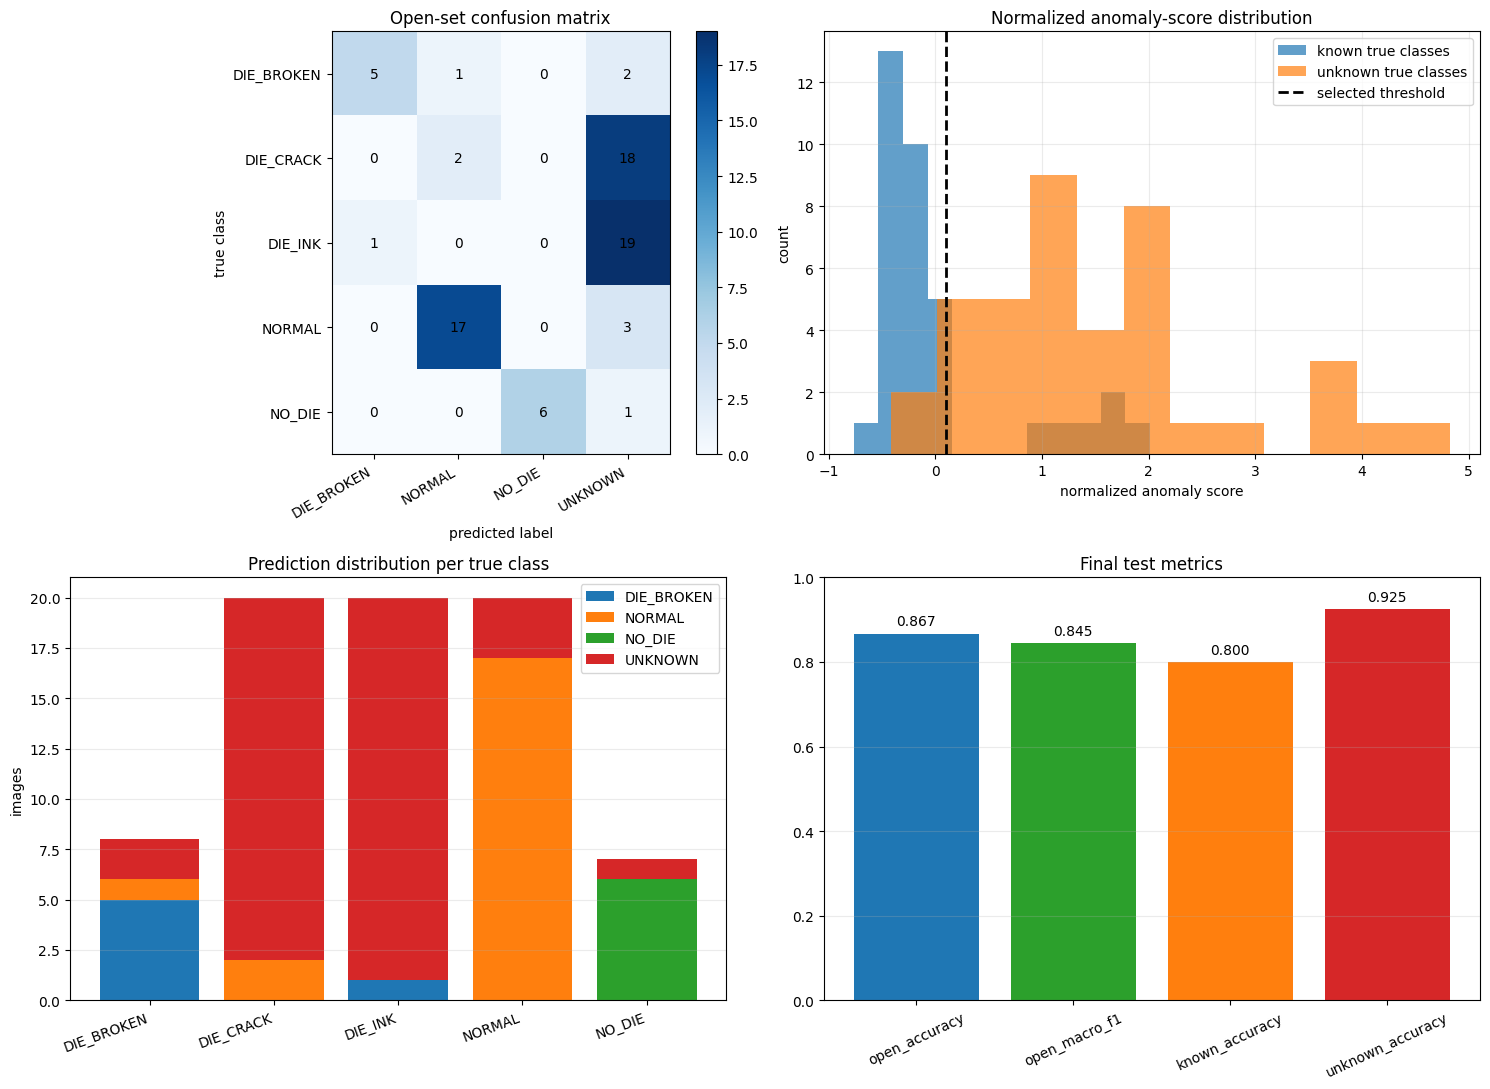

In [12]:
def plot_open_set_visualizations(rows, threshold, metrics):
    pred_names = PRED_LABELS + [UNKNOWN_PRED_NAME]
    matrix = np.zeros((len(ALL_TRUE_CLASSES), len(pred_names)), dtype=int)
    for row in rows:
        matrix[ALL_TRUE_CLASSES.index(row['true_class']), row['pred_index']] += 1

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    ax = axes[0, 0]
    im = ax.imshow(matrix, cmap='Blues')
    ax.set_title('Open-set confusion matrix')
    ax.set_xlabel('predicted label')
    ax.set_ylabel('true class')
    ax.set_xticks(np.arange(len(pred_names)))
    ax.set_xticklabels(pred_names, rotation=30, ha='right')
    ax.set_yticks(np.arange(len(ALL_TRUE_CLASSES)))
    ax.set_yticklabels(ALL_TRUE_CLASSES)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, matrix[i, j], ha='center', va='center', color='black')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[0, 1]
    known_scores = [row['normalized_anomaly_score'] for row in rows if row['true_class'] in KNOWN_LABELS]
    unknown_scores = [row['normalized_anomaly_score'] for row in rows if row['true_class'] not in KNOWN_LABELS]
    ax.hist(known_scores, bins=12, alpha=0.7, label='known true classes')
    ax.hist(unknown_scores, bins=12, alpha=0.7, label='unknown true classes')
    ax.axvline(threshold, color='black', linestyle='--', linewidth=2, label='selected threshold')
    ax.set_title('Normalized anomaly-score distribution')
    ax.set_xlabel('normalized anomaly score')
    ax.set_ylabel('count')
    ax.legend()
    ax.grid(alpha=0.25)

    ax = axes[1, 0]
    bottom = np.zeros(len(ALL_TRUE_CLASSES))
    x = np.arange(len(ALL_TRUE_CLASSES))
    for pred_idx, pred_name in enumerate(pred_names):
        values = [sum(row['true_class'] == cls and row['pred_index'] == pred_idx for row in rows) for cls in ALL_TRUE_CLASSES]
        ax.bar(x, values, bottom=bottom, label=pred_name)
        bottom += np.array(values)
    ax.set_xticks(x)
    ax.set_xticklabels(ALL_TRUE_CLASSES, rotation=20, ha='right')
    ax.set_ylabel('images')
    ax.set_title('Prediction distribution per true class')
    ax.legend()
    ax.grid(axis='y', alpha=0.25)

    ax = axes[1, 1]
    metric_names = ['open_accuracy', 'open_macro_f1', 'known_accuracy', 'unknown_accuracy']
    values = [metrics[name] for name in metric_names]
    ax.bar(metric_names, values, color=['tab:blue', 'tab:green', 'tab:orange', 'tab:red'])
    ax.set_ylim(0, 1.0)
    ax.set_title('Final test metrics')
    ax.tick_params(axis='x', rotation=25)
    for idx, value in enumerate(values):
        ax.text(idx, value + 0.02, f'{value:.3f}', ha='center')
    ax.grid(axis='y', alpha=0.25)

    plt.tight_layout()
    plt.show()


plot_open_set_visualizations(test_eval_rows, selected_threshold, test_metrics)

## Ablation visualizations

The ablation plots compare open-set method choices, ResNet feature layers, and augmentation settings using open macro F1 and accuracy metrics.

Loaded ablation metrics from: Ablation study/ablation_metrics.json


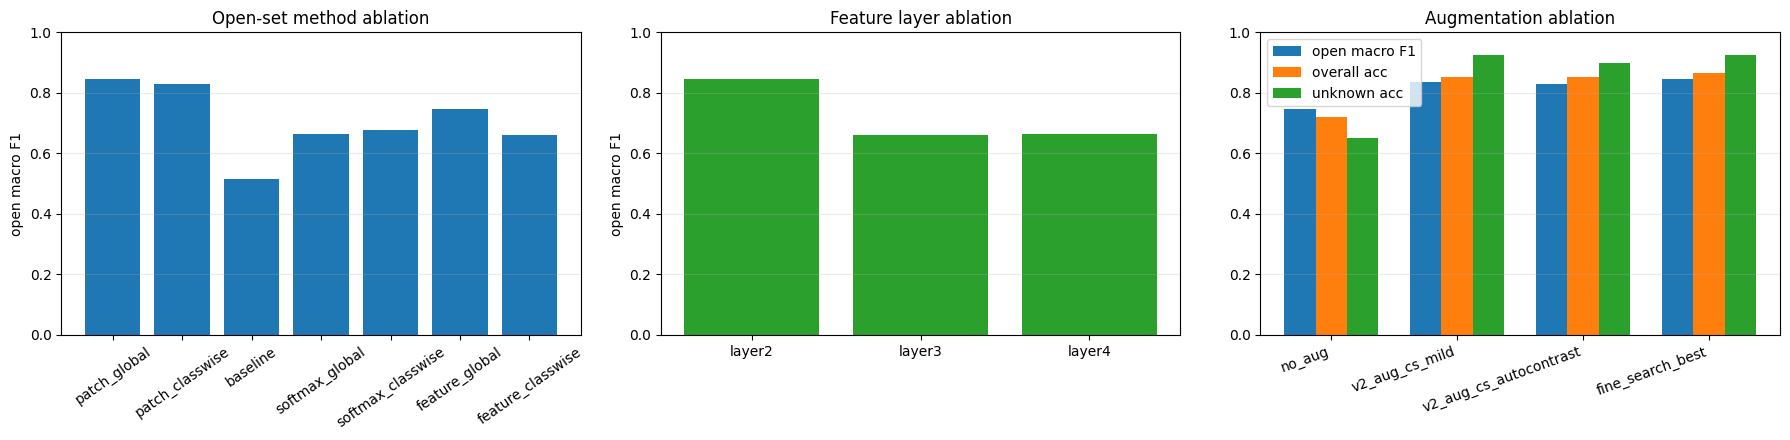

In [13]:
ABLATION_METRICS_JSON_PATH = resolve_required_json_path(ARTIFACT_PATHS['ablation_metrics_json'], 'ablation_metrics_json')
with ABLATION_METRICS_JSON_PATH.open() as f:
    ABLATION_METRICS = json.load(f)

print('Loaded ablation metrics from:', display_path(ABLATION_METRICS_JSON_PATH))

def plot_ablation_metrics(payload):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    method_items = list(payload['method_ablation'].items())
    method_names = [name for name, _ in method_items]
    method_f1 = [row['open_macro_f1'] for _, row in method_items]
    axes[0].bar(method_names, method_f1, color='tab:blue')
    axes[0].set_title('Open-set method ablation')
    axes[0].set_ylabel('open macro F1')
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis='x', rotation=35)
    axes[0].grid(axis='y', alpha=0.25)

    layer_items = list(payload['layer_ablation'].items())
    layer_names = [name for name, _ in layer_items]
    layer_f1 = [row['open_macro_f1'] for _, row in layer_items]
    axes[1].bar(layer_names, layer_f1, color='tab:green')
    axes[1].set_title('Feature layer ablation')
    axes[1].set_ylabel('open macro F1')
    axes[1].set_ylim(0, 1)
    axes[1].grid(axis='y', alpha=0.25)

    aug_rows = payload['augmentation_ablation']
    aug_names = [row['experiment'] for row in aug_rows]
    x = np.arange(len(aug_names))
    width = 0.25
    axes[2].bar(x - width, [row['open_macro_f1'] for row in aug_rows], width=width, label='open macro F1')
    axes[2].bar(x, [row['overall_acc'] for row in aug_rows], width=width, label='overall acc')
    axes[2].bar(x + width, [row['unknown_acc'] for row in aug_rows], width=width, label='unknown acc')
    axes[2].set_title('Augmentation ablation')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(aug_names, rotation=20, ha='right')
    axes[2].set_ylim(0, 1)
    axes[2].legend()
    axes[2].grid(axis='y', alpha=0.25)

    plt.tight_layout()
    plt.show()

plot_ablation_metrics(ABLATION_METRICS)
